## Versuch 4: Aufbau eines einfachen Spracherkenners

In diesem Versuch wird ein einfacher Spracherkenner entwickelt, der zur Steuerung eines Staplers in einem Hochregallager dienen könnte. Der Spracherkenner soll die vier einfachen Befehle "Hoch", "Tief", "Links" und "Rechts" erkennen.
Der Aufbau des Spracherkenners folgt dem in der Vorlesung beschriebenen Prinzip des Prototyp-Klassifikators. Die zugehörigen Spektren werden mit der Windowing-Methode berechnet.

### 1. Fourieranalyse lang andauernder Signale

Als Erstes plotten wir eine beliebige Spracheingabe, in unserem Fall das Wort "Zayne".

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import gaussian
import os

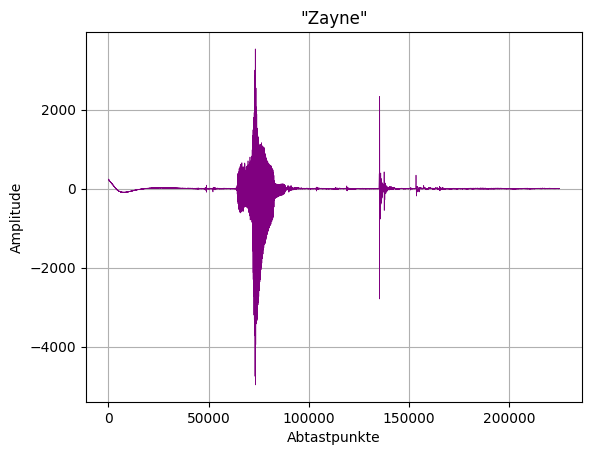

In [40]:
data = np.load('data/a1-a/zayne1733147159.npy')
plt.plot(data, linewidth=0.5, color='purple')
plt.title('"Zayne"')
plt.xlabel('Abtastpunkte')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

Als Nächstes stellen wir wieder eine Spracheingabe dar, allerdings cutten wir das Signal so, dass die Samples nahe 0 abgeschnitten werden, die vor dem eigentlichen Signal liegen. Das Signal wird auf eine Sekunde gekürzt und eventuell mit Nullen aufgefüllt.

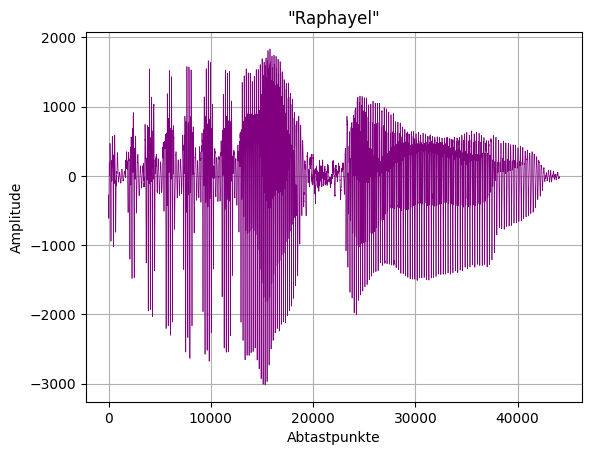

In [41]:
data = np.load('data/a1-b/raphayel1733148468.npy')
plt.plot(data, linewidth=0.5, color='purple')
plt.title('"Raphayel"')
plt.xlabel('Abtastpunkte')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

Amplitudenspektrum des ausgeschnittenen Signals berechnen und plotten.

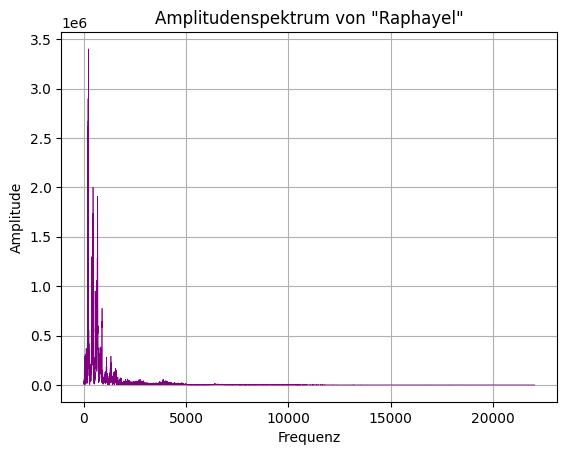

In [42]:
signal_fft = np.fft.fft(data)
amplitude_spectrum = np.abs(signal_fft)

# Nur die erste Hälfte des Spektrums betrachten, da die zweite Hälfte eine Spiegelung der ersten ist
plt.plot(amplitude_spectrum[:len(amplitude_spectrum) // 2], linewidth=0.5, color='purple')
plt.xlabel('Frequenz')
plt.ylabel('Amplitude')
plt.title('Amplitudenspektrum von "Raphayel"')
plt.grid(True)
plt.show()

Windowing-Methode anwenden und Spektrum plotten. Dafür wird das Signal in 512 Samples lange Fenster unterteilt, die sich jeweils zur Hälfte überlappen. Die Samples werden mit einer Gaußschen Fensterfunktion gewichtet, die so gewählt wird, dass die Fensterbreite 4 Standardabweichungen entspricht. Für jedes Fenster wird eine lokale Fouriertransformation durchgeführt und dann die Fouriertransformierte über alle Fenster gemittelt. Daraus wird das Amplitudenspektrum berechnet.

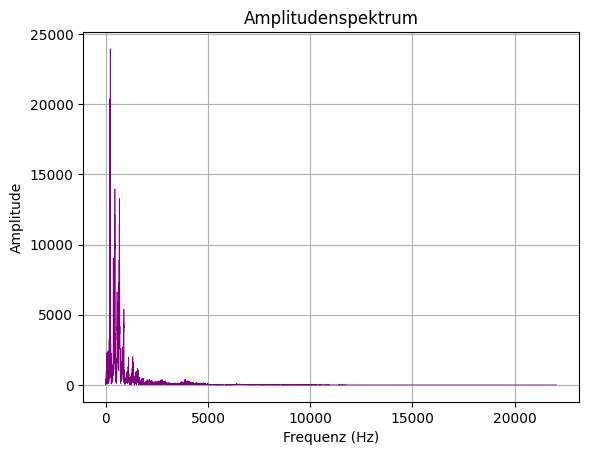

In [43]:
# Funktion zur Unterteilung eines Arrays in überlappende Fenster
def zerteilen(array, window_size=512, overlap=256):
    # Erstellen eines Gaußschen Fensters
    gauss_fenster = gaussian(window_size, window_size / 4)
    # Iteration über das Array
    for j in range(0, len(array) - window_size + 1, overlap):
        # Anwenden des Gaußschen Fensters auf das aktuelle Segment
        windowed_segment = gauss_fenster * array[j:j + window_size]
        # Auffüllen des segmentierten Fensters mit Nullen, um die ursprüngliche Länge zu erhalten
        padded_segment = np.pad(windowed_segment, (j, len(array) - (j + window_size)), 'constant')
        # Rückgabe des segmentierten und gepolsterten Fensters
        yield padded_segment

# Funktion zur Anwendung der Windowing-Methode und Berechnung der Fourier-Transformation
def windowing_func(array):
    fenster = np.array(list(zerteilen(array)))
    return np.fft.fft(fenster).mean(0)

# Anwendung der Windowing-Funktion auf die Daten
data_transformed = windowing_func(data)
fouriertransformierte = np.fft.fft(data)

frequencies = []
for i in range(len(fouriertransformierte)):
    frequencies.append(i)

# Plotten des Amplitudenspektrums des transformierten Signals
plt.plot(frequencies[:len(frequencies)//2], np.abs(data_transformed)[:len(frequencies)//2], linewidth=0.5, color='purple')
plt.xlabel('Frequenz (Hz)')
plt.ylabel('Amplitude')
plt.title("Amplitudenspektrum")
plt.grid()
plt.show()

### 2. Spracherkennung

Wir berechnen das Referenzspektrum durch Mittelung über die 5 Spektren und stellen die 4 Referenzspektren dar.

#### "Hoch"

In [44]:
# Method to compute and plot the reference spectrum for a given path
def plot_reference_spectrum(folder_path):
    # Load all .npy files in the folder
    data_files = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.npy')]

    # Compute the spektren for each file
    spektren = []
    for file in data_files:
        data = np.load(file)
        spectrum = windowing_func(data)
        spektren.append(spectrum)

    # Average the spektren to obtain the reference spectrum
    reference_spectrum = np.mean(spektren, axis=0)
    np.save(f'{folder_path}/reference_spectrum.npy', reference_spectrum)

    # Plot the reference spectrum
    frequencies = np.fft.fftfreq(len(reference_spectrum))
    plt.plot(frequencies[:len(frequencies)//2], np.abs(reference_spectrum)[:len(frequencies)//2], linewidth=0.5, color='purple')
    plt.xlabel('Frequenz (Hz)')
    plt.ylabel('Amplitude')
    plt.title(f'Referenzspektrum für \"{os.path.basename(folder_path)}\"')
    plt.grid(True)
    plt.show()

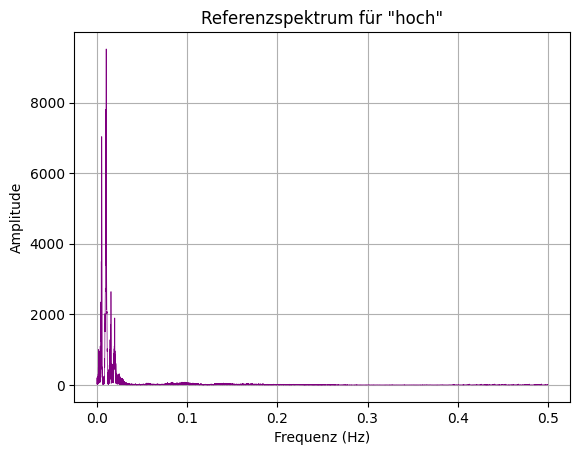

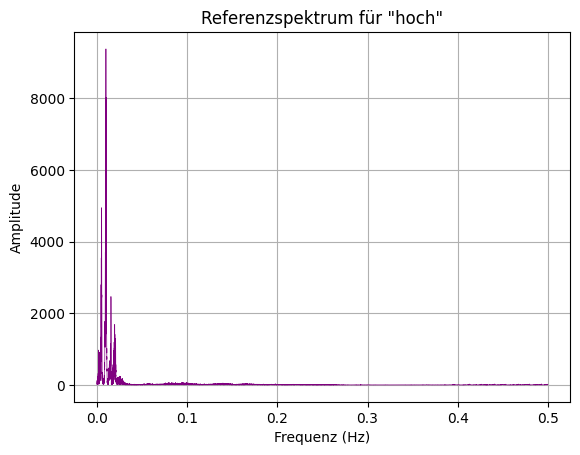

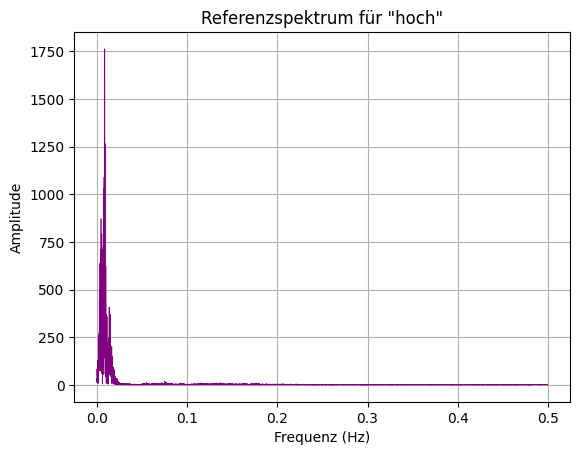

In [45]:
plot_reference_spectrum('data/a2-a/hoch')
plot_reference_spectrum('data/a2-b/a/hoch')
plot_reference_spectrum('data/a2-b/b/hoch')

#### "Tief"

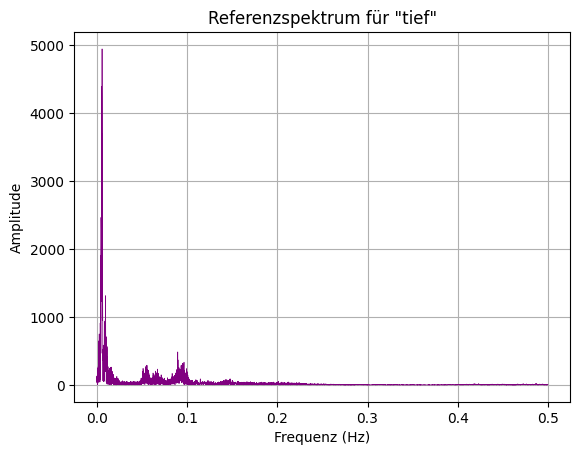

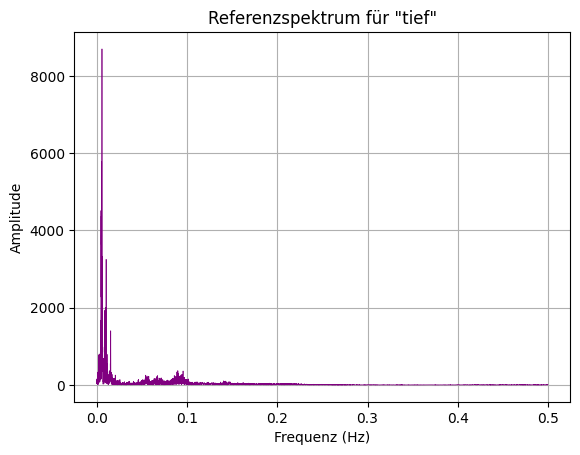

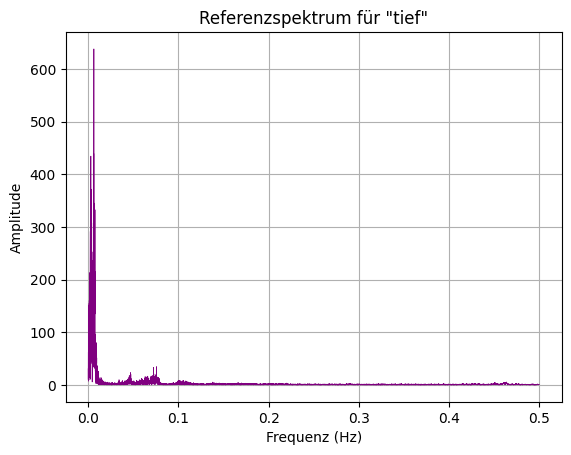

In [46]:
plot_reference_spectrum('data/a2-a/tief')
plot_reference_spectrum('data/a2-b/a/tief')
plot_reference_spectrum('data/a2-b/b/tief')

#### "Links"

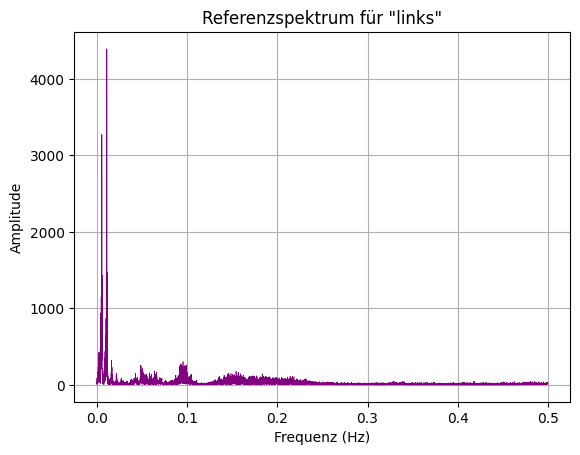

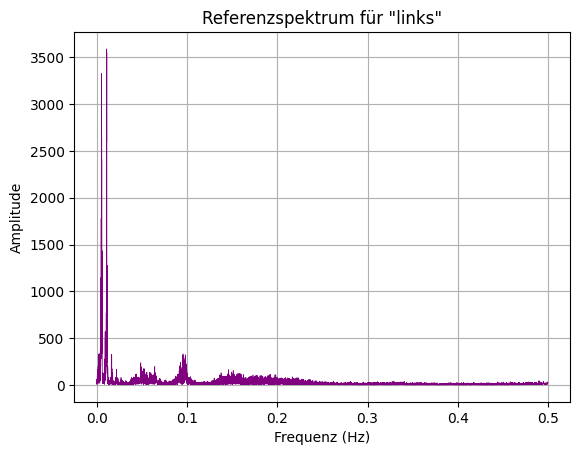

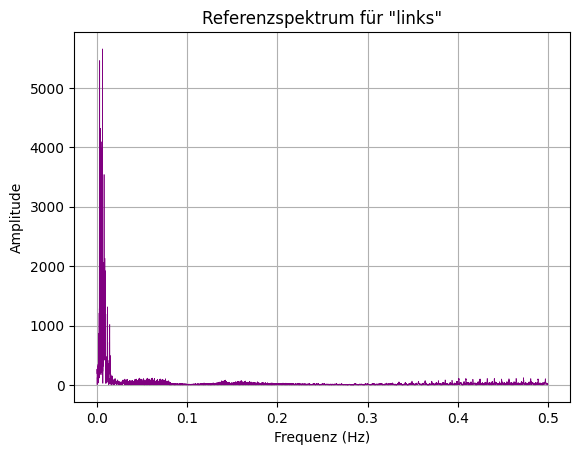

In [47]:
plot_reference_spectrum('data/a2-a/links')
plot_reference_spectrum('data/a2-b/a/links')
plot_reference_spectrum('data/a2-b/b/links')

#### "Rechts"

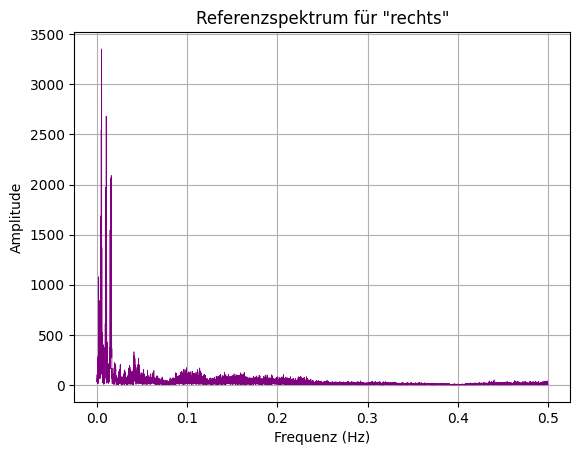

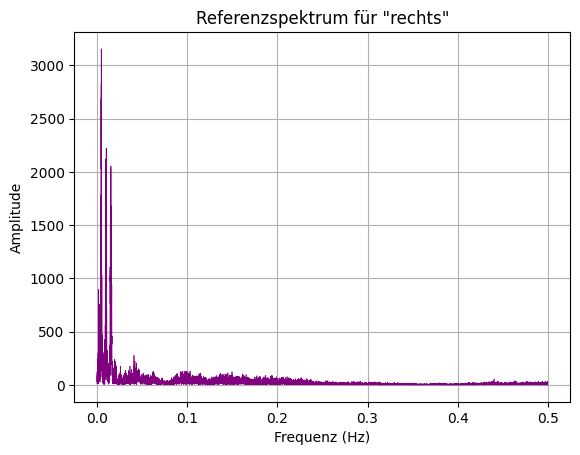

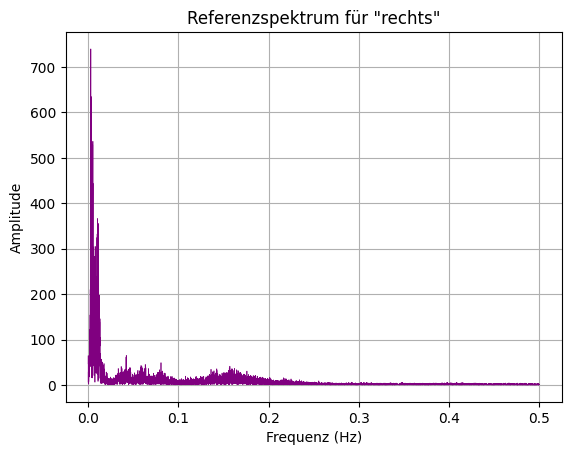

In [48]:
plot_reference_spectrum('data/a2-a/rechts')
plot_reference_spectrum('data/a2-b/a/rechts')
plot_reference_spectrum('data/a2-b/b/rechts')

Routine zur Berechnung des Korrelationskoeffizienten nach Bravais-Pearson zum Vergleich zweier Eingabespektren

In [49]:
def pearson_correlation(x, y):
    # Ensure the input spectra are real-valued
    x = np.real(x)
    y = np.real(y)
    
    # Berechnung der Mittelwerte
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    # Berechnung der Abweichungen von den Mittelwerten
    diff_x = x - mean_x
    diff_y = y - mean_y

    # Berechnung der Kovarianz
    covariance = np.sum(diff_x * diff_y)

    # Berechnung der Standardabweichungen
    std_x = np.sqrt(np.sum(diff_x ** 2))
    std_y = np.sqrt(np.sum(diff_y ** 2))

    # Berechnung des Korrelationskoeffizienten
    correlation = covariance / (std_x * std_y)

    return correlation

In [56]:
# Testen der Routine an den Referenzspektren
spectrum_hoch = np.load('data/a2-a/hoch/reference_spectrum.npy')
spectrum_links = np.load('data/a2-a/links/reference_spectrum.npy')
spectrum_rechts = np.load('data/a2-a/rechts/reference_spectrum.npy')
spectrum_tief = np.load('data/a2-a/tief/reference_spectrum.npy')
spectrum_test = np.load('data/a2-b/a/hoch/reference_spectrum.npy')

print(f'Korrelation identischer Spektren: {pearson_correlation(spectrum_hoch, spectrum_hoch)}')
print(f'Korrelation verschiedener Spektren: {pearson_correlation(spectrum_rechts, spectrum_test)}')

Korrelation identischer Spektren: 1.0000000000000002
Korrelation verschiedener Spektren: -0.020360054942413216


In [74]:
# Funktion zur Spracherkennung
def sprach_erkenner(path):
    inputfi = np.load(path)
    ip = np.abs(windowing_func(inputfi))
    korr_hoch = pearson_correlation(spectrum_hoch, ip)
    korr_tief = pearson_correlation(spectrum_tief, ip)
    korr_rechts = pearson_correlation(spectrum_rechts, ip)
    korr_links = pearson_correlation(spectrum_links, ip)
    correlations = {'hoch': korr_hoch, 'tief': korr_tief, 'rechts': korr_rechts, 'links': korr_links}
    return max(correlations, key=correlations.get)

# Testen der Spracherkennung
def test_spracherkenner(test_folder, expected_command):
    test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.npy')]
    correct = 0
    for file in test_files:
        result = sprach_erkenner(file)
        if result == expected_command:
            correct += 1
    total = len(test_files)
    return correct, total

# Testen an beiden Datensätzen
results = {}
for command in ['hoch', 'tief', 'links', 'rechts']:
    correct_a, total_a = test_spracherkenner(f'data/a2-b/a/{command}', command)
    correct_b, total_b = test_spracherkenner(f'data/a2-b/b/{command}', command)
    results[command] = {'correct_a': correct_a, 'total_a': total_a, 'correct_b': correct_b, 'total_b': total_b}

# Berechnung der Detektions- und Fehlerrate
for command, result in results.items():
    detection_rate_a = result['correct_a'] / result['total_a'] * 100
    detection_rate_b = result['correct_b'] / result['total_b'] * 100
    print(f'{command}')
    print(f'A - Detektionsrate: {detection_rate_a:.2f}%, Fehlerrate: {100 - detection_rate_a:.2f}%')
    print(f'B - Detektionsrate: {detection_rate_b:.2f}%, Fehlerrate: {100 - detection_rate_b:.2f}%\n')


hoch
A - Detektionsrate: 0.00%, Fehlerrate: 100.00%
B - Detektionsrate: 66.67%, Fehlerrate: 33.33%

tief
A - Detektionsrate: 0.00%, Fehlerrate: 100.00%
B - Detektionsrate: 0.00%, Fehlerrate: 100.00%

links
A - Detektionsrate: 16.67%, Fehlerrate: 83.33%
B - Detektionsrate: 0.00%, Fehlerrate: 100.00%

rechts
A - Detektionsrate: 33.33%, Fehlerrate: 66.67%
B - Detektionsrate: 0.00%, Fehlerrate: 100.00%

